# DemoMA_MCClassification_CCGPMA
### This demo shows an example of Multi-class classification with multiple annotators by using our model based on chained Gaussian processes for multiple annotators (GGPMA) and correlated chained Gaussian processes for multiple annotators (CCGPMA).

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
%%bash
python3 -m venv /opt/gpflow_env --without-pip
curl -sS https://bootstrap.pypa.io/get-pip.py | /opt/gpflow_env/bin/python3
/opt/gpflow_env/bin/pip install -q --upgrade pip setuptools wheel
/opt/gpflow_env/bin/pip install -q tensorflow==2.16.2 tensorflow-probability==0.24.0 gpflow==2.9.2 gpflux==0.4.4 numpy==1.26.4 scikit-learn matplotlib pandas
echo "Setup OK"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.1 MB/s  0:00:00
Setup OK


In [ ]:
script = r"""
import os
os.environ['MPLBACKEND'] = 'Agg'
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import tensorflow as tf
import gpflow as gpf
import gpflux
import random

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from gpflow.quadrature.deprecated import ndiagquad, ndiag_mc
from check_shapes import inherit_check_shapes

random.seed(100)
gpf.config.set_default_float(np.float64)
np.random.seed(0)

# ============================================================
# Funciones auxiliares
# ============================================================
def one_of_K(y, K):
    Yhat = np.ones((y.shape[0], K))
    for k in range(K):
        Yhat[:,k,None] = (y==k+1).astype(int)
    return Yhat

def Sigmoid(f_r):
    return 1/(1 + np.exp(-f_r))

def Softmax(A):
    num = np.exp(A)
    den = np.sum(num, 1)[:,np.newaxis]
    return num/den

def MAjVot(Y, K):
    N, R = Y.shape
    Yhat = np.zeros((N,1))
    for n in range(N):
        votes = np.zeros((K,1))
        for r in range(R):
            for k in range(K):
                if Y[n,r] == k+1:
                    votes[k] += 1
        Yhat[n] = np.argmax(votes) + 1
    return Yhat

# ============================================================
# 1. Generación de datos
# ============================================================
N = 300
np.random.seed(1)
X = np.random.rand(N,1)

t1 = (np.sin(2*np.pi*X)).reshape(N,1)
t2 = (-np.sin(2*np.pi*X)).reshape(N,1)
t3 = (-np.sin(2*np.pi*(X+0.25))+0.5).reshape(N,1)
t = np.concatenate((t1, t2, t3), axis=1)

idx = np.argsort(X, axis=0).flatten()
X = X[idx]
t = t[idx,:]
y = np.array(np.argmax(t, 1).reshape(-1,1), dtype=float)+1
K = len(np.unique(y))
Yhat = one_of_K(y, K)

# Train / Test split
seed = 1
np.random.seed(seed)
Ntest = 200

Xtrain = X.reshape((N,1))
ytrain = y

Xtest = np.linspace(0, 1, Ntest).reshape((Ntest,1))
t1 = (np.sin(2*np.pi*Xtest)).reshape(Ntest,1)
t2 = (-np.sin(2*np.pi*Xtest)).reshape(Ntest,1)
t3 = (-np.sin(2*np.pi*(Xtest+0.25))+0.5).reshape(Ntest,1)
ttest = np.concatenate((t1, t2, t3), axis=1)
ytest = np.array(np.argmax(ttest, 1).reshape(-1,1), dtype=float)+1

# ============================================================
# 2. Simulación de anotadores
# ============================================================
R = 5
NrP = 1.0

u_q = np.empty((Xtrain.shape[0],3))
u_q[:,0,None] = 4.5*np.cos(2*np.pi*Xtrain + 1.5*np.pi) - 3*np.sin(4.3*np.pi*Xtrain + 0.3*np.pi)
u_q[:,1,None] = 4.5*np.cos(1.5*np.pi*Xtrain + 0.5*np.pi) + 5*np.sin(3*np.pi*Xtrain + 1.5*np.pi)
u_q[:,2,None] = 1

W = []
W.append(np.array([[0.4],[0.7],[-0.5],[0],[-0.7]]))
W.append(np.array([[0.4],[-1.0],[-0.1],[-0.8],[1.0]]))
W.append(np.array([[3.1],[-1.8],[-0.6],[-1.2],[1.0]]))

F_r, Lam_r = [], []
for r in range(R):
    f_r = np.zeros((Xtrain.shape[0], 1))
    for q in range(3):
        f_r += W[q][r].T * u_q[:,q,None]
    F_r.append(f_r)
    lam_r = Sigmoid(f_r)
    lam_r[lam_r>0.5] = 1
    lam_r[lam_r<=0.5] = 0
    Lam_r.append(lam_r)

seed = 100
np.random.seed(seed)
Ytrain = np.ones((N, R))
for r in range(R):
    aux = ytrain.copy()
    for n in range(N):
        if Lam_r[r][n] == 0:
            labels = np.arange(1, K+1)
            a = np.where(labels==ytrain[n])
            labels = np.delete(labels, a)
            idxlabels = np.random.permutation(K-1)
            aux[n] = labels[idxlabels[0]]
    Ytrain[:,r] = aux.flatten()

np.random.seed(seed)
iAnn = np.zeros((N, R), dtype=int)
Nr = np.ones((R), dtype=int)*int(np.floor(N*NrP))
for r in range(R):
    if r < R-1:
        indexR = np.random.permutation(range(N))[:Nr[r]]
        iAnn[indexR,r] = 1
    else:
        iSimm = np.sum(iAnn, axis=1)
        idxZero = np.asarray([i for (i, val) in enumerate(iSimm) if val == 0])
        Nzeros = idxZero.shape[0]
        idx2Choose = np.arange(N)
        if Nzeros == 0:
            indexR = np.random.permutation(range(N))[:Nr[r]]
            iAnn[indexR,r] = 1
        else:
            idx2Choose = np.delete(idx2Choose, idxZero)
            N2chose = idx2Choose.shape[0]
            idxNoZero = np.random.permutation(N2chose)[:(Nr[r] - Nzeros)]
            idxTot = np.concatenate((idxZero, idx2Choose[idxNoZero]))
            iAnn[idxTot,r] = 1

Vref = -1e-20
for r in range(R):
    Ytrain[iAnn[:,r] == 0, r] = Vref

Xtrain = np.asarray(Xtrain).astype(np.float64)
Ytrain = np.asarray(Ytrain).astype(np.float64)

# ============================================================
# 3. Likelihood personalizada
# ============================================================
class multiClassMA(gpf.likelihoods.Likelihood):
    def __init__(self, num_classes, num_ann):
        super().__init__(input_dim=None, latent_dim=num_classes+num_ann, observation_dim=None)
        self.K = num_classes
        self.R = num_ann

    @inherit_check_shapes
    def _log_prob(self, X, F, Y):
        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth=self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)
        zeta = tf.repeat(tf.expand_dims(tf.nn.softmax(F[:,:self.K]), axis=-1), self.R, axis=-1)
        lamb = tf.nn.sigmoid(F[:,self.K:])
        CE   = tf.math.reduce_sum(Yh*tf.math.log(zeta), axis=1)
        return -tf.math.reduce_sum((lamb*CE - (1-lamb)*np.log(self.K)), axis=1)

    def _variational_expectations(self, X, Fmu, Fvar, Y):
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]
        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth=self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)
        Elog  = ndiag_mc(self.log_softmax, 800, m_f, v_f, False)
        Elog_ = tf.repeat(tf.expand_dims(Elog, axis=-1), self.R, axis=-1)
        C_E   = tf.math.reduce_sum((Yh*Elog_), axis=1)
        Eq_g  = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)
        return tf.math.reduce_sum((Eq_g*C_E - (1-Eq_g)*np.log(self.K)), axis=1)

    def _predict_mean_and_var(self, X, Fmu, Fvar):
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]
        Ez   = ndiag_mc(tf.nn.softmax, 800, m_f, v_f, False)
        El   = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)
        Ez_2 = ndiag_mc(self.softmax_2, 800, m_f, v_f, False)
        El_2 = ndiagquad(self.sigmoid_2, 20, m_g, v_g, False)
        return tf.concat([Ez, El], axis=1), tf.concat([Ez_2-Ez**2, El_2-El**2], axis=1)

    def _predict_log_density(self, F):
        raise NotImplementedError

    def log_softmax(self, F):
        return tf.math.log(tf.nn.softmax(F))

    def softmax_2(self, F):
        return tf.math.square(tf.nn.softmax(F))

    def sigmoid_2(self, F):
        return tf.math.square(tf.nn.sigmoid(F))

# ============================================================
# 4. Modelo Deep GP
# ============================================================
M = 10
L = R + K
Z = np.linspace(X.min(), X.max(), M).reshape(-1, 1)

kernel1 = gpf.kernels.SquaredExponential(variance=0.5, lengthscales=1)
inducing_variable1 = gpf.inducing_variables.InducingPoints(Z.copy())
gp_layer1 = gpflux.layers.GPLayer(
    kernel1, inducing_variable1, num_data=N, num_latent_gps=3,
    mean_function=gpf.mean_functions.Zero()
)

Z2 = np.linspace(X.min(), X.max(), M).reshape(-1, 1).repeat(3, axis=1)
kernel2 = gpf.kernels.SquaredExponential(variance=0.5, lengthscales=1)
inducing_variable2 = gpf.inducing_variables.InducingPoints(Z2.copy())
gp_layer2 = gpflux.layers.GPLayer(
    kernel2, inducing_variable2, num_data=N, num_latent_gps=L,
    mean_function=gpf.mean_functions.Zero()
)

likelihood_layer = gpflux.layers.LikelihoodLayer(multiClassMA(K, R))
two_layer_dgp = gpflux.models.DeepGP(
    f_layers=[gp_layer1, gp_layer2],
    likelihood=likelihood_layer,
    input_dim=1
)
model = two_layer_dgp.as_training_model()
model.compile(gpf.keras.tf_keras.optimizers.Adam(0.01))

# ============================================================
# 5. Entrenamiento
# ============================================================
history = model.fit(
    {"inputs": Xtrain, "targets": Ytrain},
    batch_size=100,
    epochs=1000,
    verbose=1
)

# ============================================================
# 6. Predicciones
# ============================================================
f_distribution = model({"inputs": Xtest, "targets": ytest})
pY  = f_distribution.y_mean.numpy()
pYv = f_distribution.y_var.numpy()

# ============================================================
# 7. Guardar resultados
# ============================================================
np.save("/tmp/pY.npy",           pY)
np.save("/tmp/pYv.npy",          pYv)
np.save("/tmp/Xtest.npy",        Xtest)
np.save("/tmp/Xtrain.npy",       Xtrain)
np.save("/tmp/ytest.npy",        ytest)
np.save("/tmp/history_loss.npy", np.array(history.history["loss"]))
np.save("/tmp/K.npy",            np.array([K]))
np.save("/tmp/R.npy",            np.array([R]))
for r in range(R):
    np.save(f"/tmp/Lam_r_{r}.npy", Lam_r[r])

# ============================================================
# 8. Plot: curva de entrenamiento
# ============================================================
plt.figure()
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.savefig('/tmp/training_loss.png', dpi=150, bbox_inches='tight')
plt.close()

# ============================================================
# 9. Plot: resultados finales
# ============================================================
Mc = pY
Vc = np.abs(pYv)
Yhat_test = np.ones((ytest.shape[0], K))
for k in range(K):
    Yhat_test[:,k] = (ytest.flatten()==k+1).astype(int)

plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.figure(figsize=(15, 20))

for r in range(R+1):
    miny, maxy = 0, 1
    if r == 0:
        plt.subplot(R+1, 3, 3*r+1)
        plt.plot(Xtest, Yhat_test, linewidth=2, alpha=1)
        plt.ylabel("Classification", fontsize=14)
        plt.ylim(miny-0.1, maxy+0.1)
    else:
        plt.subplot(R+1, 3, 3*r+1)
        plt.plot(Xtrain, Lam_r[r-1], 'b-', linewidth=2, alpha=1)
        plt.ylabel(f"$\\lambda_{r}$", fontsize=18)
        plt.ylim(-0.1, 1.1)

    if r > 0:
        mfc = Mc[:, K+r-1]
        vfc = Vc[:, K+r-1]
        plt.subplot(R+1, 3, 3*r+2)
        plt.plot(Xtest, mfc, 'b-', linewidth=2, alpha=1)
        plt.plot(Xtest, mfc + 2*np.sqrt(vfc), 'b-', linewidth=4, alpha=0.25)
        plt.plot(Xtest, mfc - 2*np.sqrt(vfc), 'b-', linewidth=4, alpha=0.25)
        plt.ylim(-0.1, 1.1)
    else:
        mfc = Mc[:, :K]
        vfc = Vc[:, :K]
        plt.subplot(R+1, 3, 3*r+2)
        plt.plot(Xtest, mfc, linewidth=2, alpha=1)
        plt.gca().set_prop_cycle(None)
        plt.plot(Xtest, mfc + 2*np.sqrt(vfc), linewidth=4, alpha=0.25)
        plt.gca().set_prop_cycle(None)
        plt.plot(Xtest, mfc - 2*np.sqrt(vfc), linewidth=4, alpha=0.25)
        plt.ylim(miny-0.1, maxy+0.1)

auxM = np.array(np.argmax(Mc[:,:K], 1).reshape(-1,1), dtype=float)+1
AccCCGP  = accuracy_score(ytest, auxM)
AUC_CCGP = roc_auc_score(Yhat_test, Mc[:,:K])
NMI_CCGP = normalized_mutual_info_score(ytest.flatten(), auxM.flatten())

plt.subplot(R+1, 3, 1)
plt.title('Ground truth and real reliabilities')
plt.subplot(R+1, 3, 2)
plt.title(f'NMI={NMI_CCGP*100:.2f}, AUC={AUC_CCGP*100:.2f}, Acc={AccCCGP*100:.2f}')
plt.savefig('/tmp/resultados.png', dpi=150, bbox_inches='tight')
plt.close()

print(f"DONE | NMI={NMI_CCGP*100:.2f}% | AUC={AUC_CCGP*100:.2f}% | Acc={AccCCGP*100:.2f}%")
"""

with open("/tmp/run_gpflow.py", "w") as f:
    f.write(script)
print("Script escrito OK")

Script escrito OK


In [ ]:
%%bash
/opt/gpflow_env/bin/pip install -q --force-reinstall setuptools==69.5.1
/opt/gpflow_env/bin/python3 -c "import pkg_resources; print('pkg_resources OK')"

pkg_resources OK


<string>:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html


In [ ]:
import subprocess, os

env = os.environ.copy()
env['MPLBACKEND'] = 'Agg'
env['TF_USE_LEGACY_KERAS'] = '1'

result = subprocess.run(
    ["/opt/gpflow_env/bin/python", "/tmp/run_gpflow.py"],
    capture_output=True, text=True, env=env
)
# Mostrar progreso del entrenamiento (últimas 50 líneas)
print(result.stdout[-4000:])
if result.returncode != 0:
    print("--- STDERR ---")
    print(result.stderr[-3000:])


3/3 [==============================] - 0s 18ms/step - loss: 3.2643 - gp_layer_prior_kl: 0.1211 - gp_layer_1_prior_kl: 0.3455
Epoch 991/1000

3/3 [==============================] - 0s 19ms/step - loss: 3.2721 - gp_layer_prior_kl: 0.1206 - gp_layer_1_prior_kl: 0.3453
Epoch 992/1000

3/3 [==============================] - 0s 19ms/step - loss: 3.2632 - gp_layer_prior_kl: 0.1201 - gp_layer_1_prior_kl: 0.3457
Epoch 993/1000

3/3 [==============================] - 0s 17ms/step - loss: 3.2751 - gp_layer_prior_kl: 0.1196 - gp_layer_1_prior_kl: 0.3464
Epoch 994/1000

3/3 [==============================] - 0s 18ms/step - loss: 3.2602 - gp_layer_prior_kl: 0.1197 - gp_layer_1_prior_kl: 0.3468
Epoch 995/1000

3/3 [==============================] - 0s 18ms/step - loss: 3.2468 - gp_layer_prior_kl: 0.1200 - gp_layer_1_prior_kl: 0.3468
Epoch 996/1000

3/3 [==============================] - 0s 18ms/step - loss: 3.2416 - gp_layer_prior_kl: 0.1199 - gp_layer_1_prior_kl: 0.3467


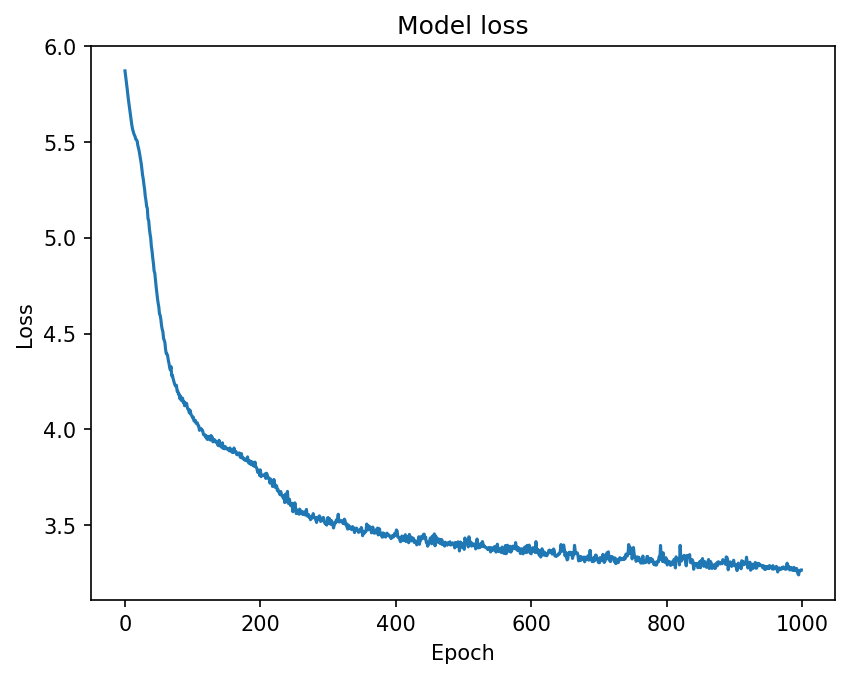

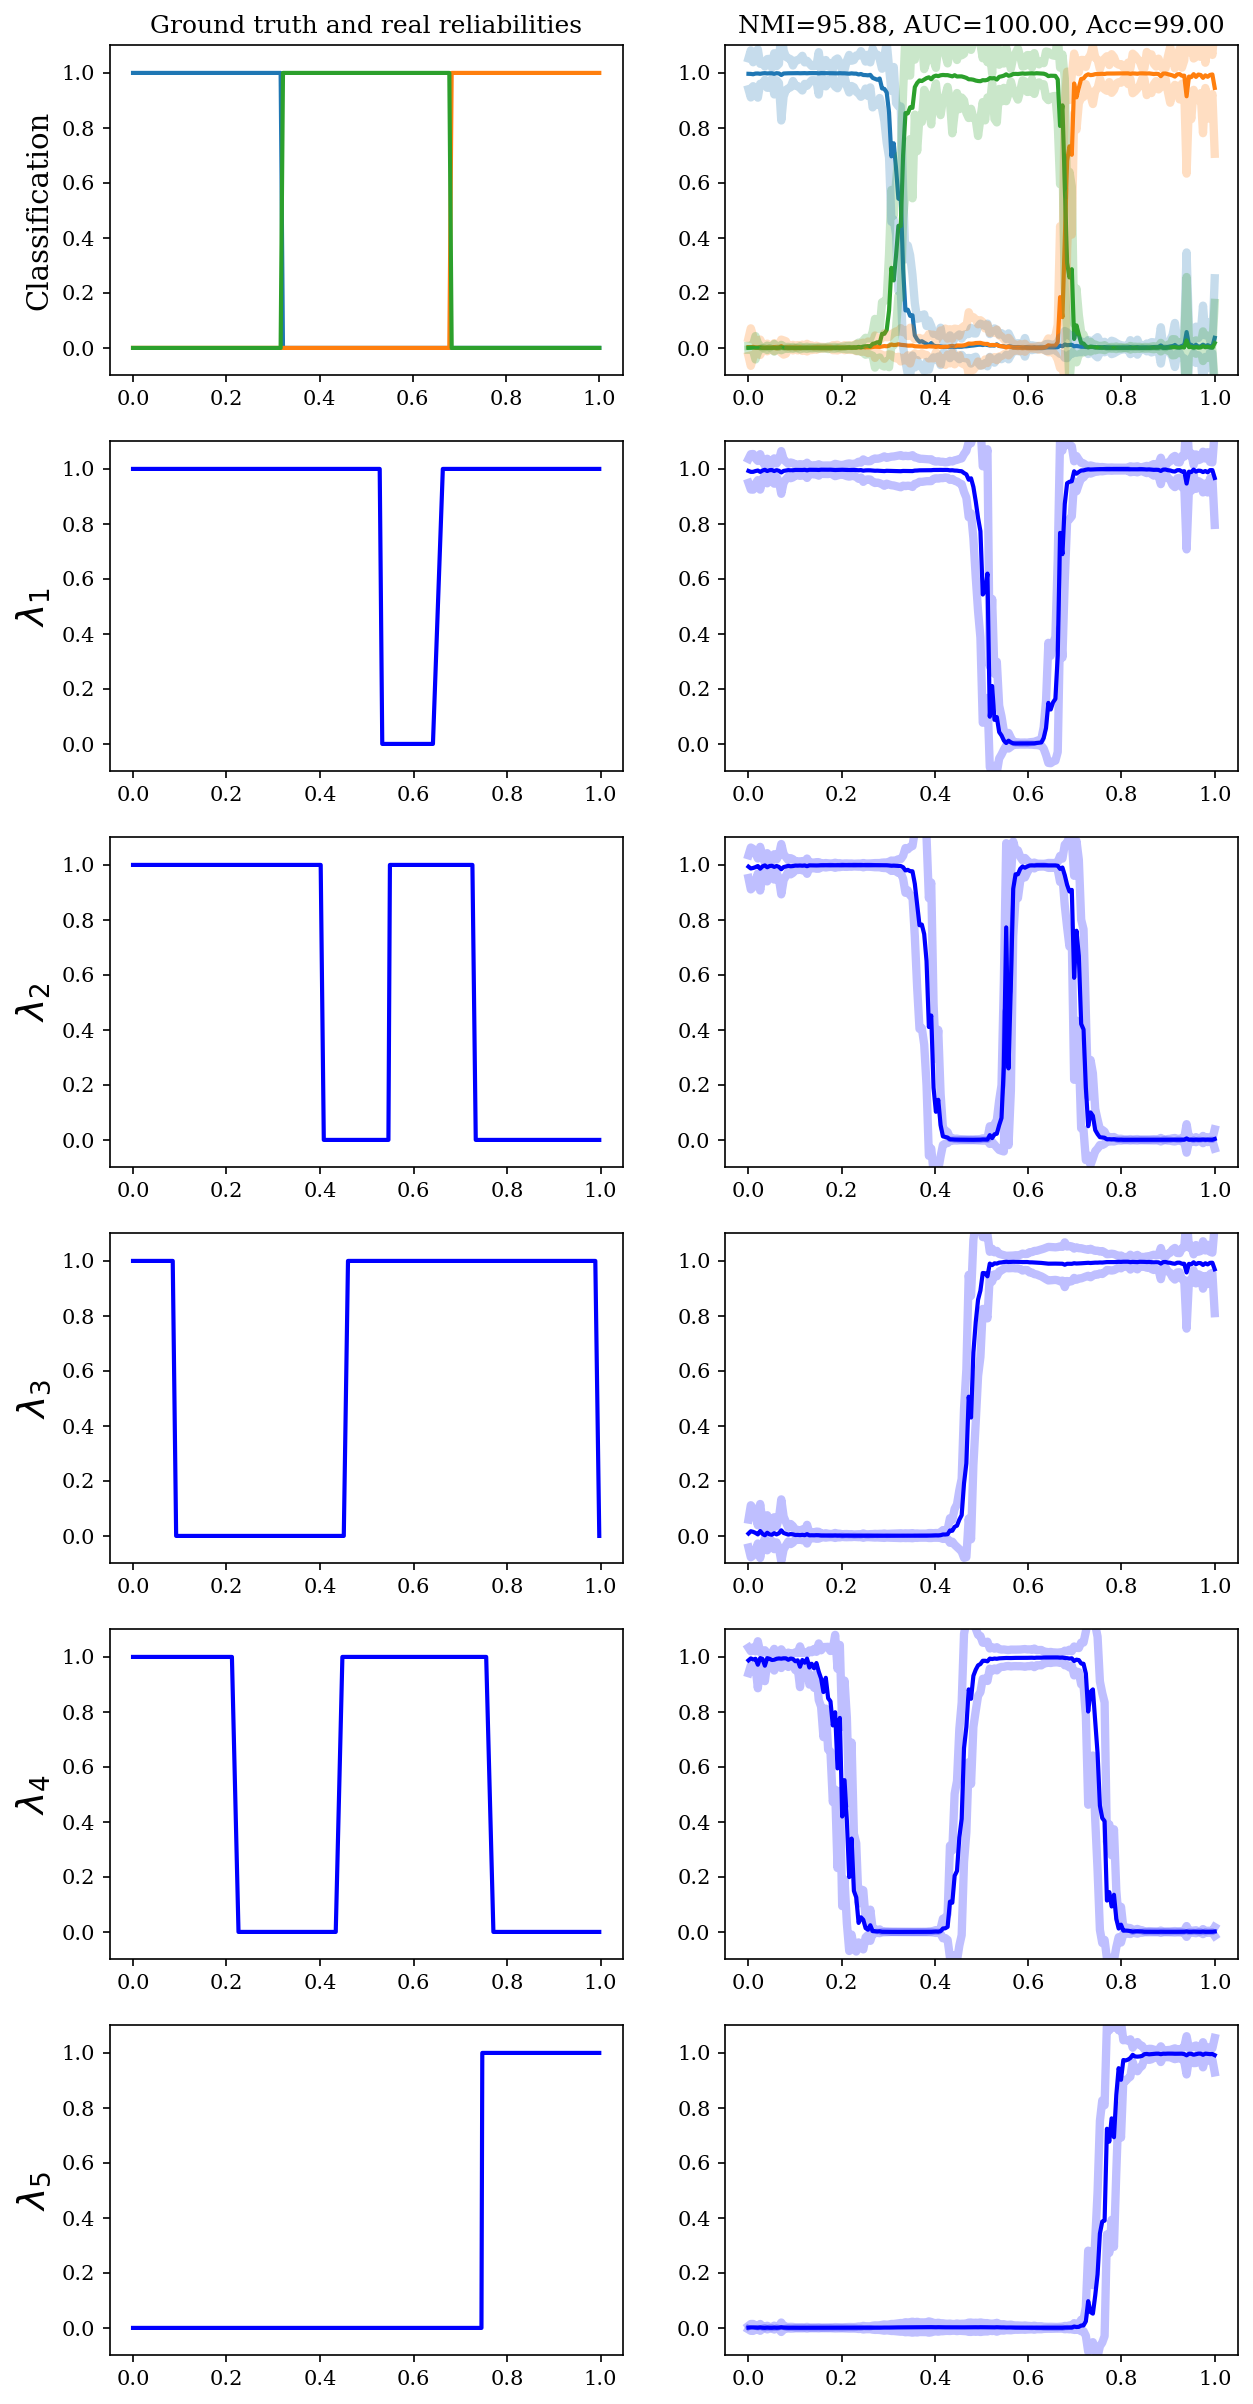

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Curva de entrenamiento
display(Image('/tmp/training_loss.png'))

# Resultados finales
display(Image('/tmp/resultados.png'))

# Métricas (ya impresas en stdout, pero también disponibles aquí)
pY    = np.load("/tmp/pY.npy")
pYv   = np.load("/tmp/pYv.npy")
ytest = np.load("/tmp/ytest.npy")
K     = int(np.load("/tmp/K.npy")[0])
R     = int(np.load("/tmp/R.npy")[0])

## Some useful functions

In [ ]:
# One-of-K codification.
def one_of_K(y, K):
    Yhat = np.ones((y.shape[0], K))
    for k in range(K):
        Yhat[:,k,None] = (y==k+1).astype(int)
    return Yhat

#Defining the Sigmoid function and Softmax function
def Sigmoid(f_r):
    lam_r = 1/(1 + np.exp(-f_r))
    return lam_r

def Softmax(A):
    num = np.exp(A)
    den = np.sum(num, 1)
    den = den[:,np.newaxis]
    zeta_k = num/den
    return zeta_k

#Hard estimation of the ground truth by using the MAjority Voting scheme.
def MAjVot(Y, K):
    N,R = Y.shape
    Yhat = np.zeros((N,1))
    for n in range(N):
        votes = np.zeros((K,1))
        for r in range(R):
            for k in range(K):
                if Y[n,r] == k+1:
                    votes[k] = votes[k]+1
        Yhat[n] = np.argmax(votes) + 1
    return Yhat

## 1. Multi-class classification problem definition

We assume a 1D multi-class classification problem, where input features are given as $x \in [0, 1]$ and the outputs are generated as follows

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, normalized_mutual_info_score
import pandas as pd

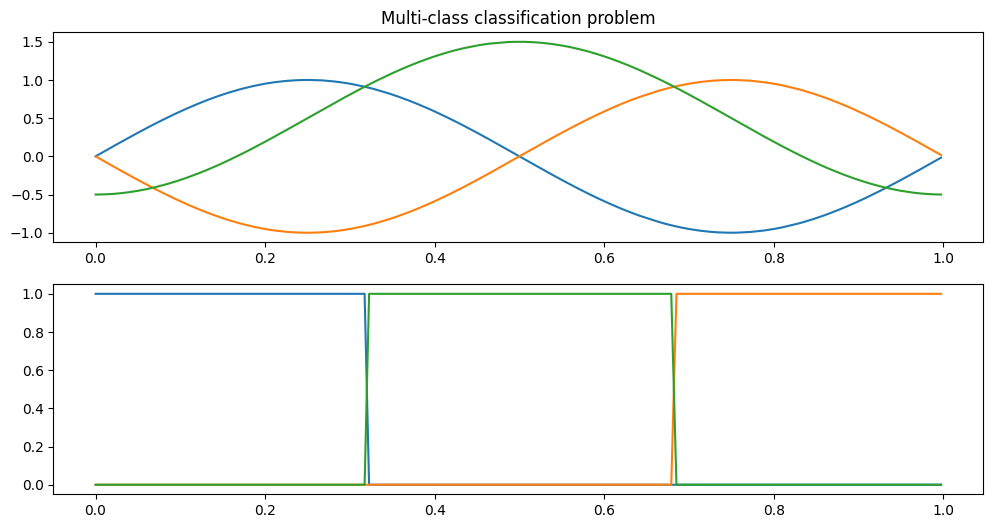

In [ ]:
N = 300

np.random.seed(1)
X = np.random.rand(N,1)

t1 = (np.sin(2*np.pi*X)).reshape(N,1)
t2 = (-np.sin(2*np.pi*X)).reshape(N,1)
t3 = (-np.sin(2*np.pi*(X+0.25))+0.5).reshape(N,1)
t = np.concatenate((t1, t2, t3), axis=1)

idx = np.argsort(X, axis=0).flatten()
X = X[idx]
t = t[idx,:]
y = np.array(np.argmax(t, 1).reshape(-1,1), dtype=float)+1
K = len(np.unique(y))

# The true labels in codification 1-of-K
Yhat = one_of_K(y, K)

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(X, t)
plt.title('Multi-class classification problem')
plt.subplot(2,1,2)
plt.plot(X, Yhat)
plt.show()

To define the training set, we randomly obtain $N=100$ samples from the interval $[0, 1]$. Conversely, for the test set, we sample uniformly $200$ points from $[0, 1]$

In [ ]:
seed = 1
np.random.seed(seed)
Ntest = 200

# The training set
Xtrain = X
Xtrain = Xtrain.reshape((N,1))
ytrain = y

# The test set
Xtest = np.linspace(0, 1, Ntest).reshape((Ntest,1))
t1 = (np.sin(2*np.pi*Xtest)).reshape(Ntest,1)
t2 = (-np.sin(2*np.pi*Xtest)).reshape(Ntest,1)
t3 = (-np.sin(2*np.pi*(Xtest+0.25))+0.5).reshape(Ntest,1)
ttest = np.concatenate((t1, t2, t3), axis=1)
ytest = np.array(np.argmax(ttest, 1).reshape(-1,1), dtype=float)+1

## 2. Multiple annotators simulation

To simulate labels from multiple annotators, we assume them to correspond to corrupted versions of the ground truth. Thus, the labels are simulated by following approach:
1. For each annotator $r$, we compute a function $f_r(\cdot)$ as a combination of $Q$ latent functions $u_q(\cdot)$, with $q\in\{1, \dots , Q\}$.
2. We compute the annotators' reliability $\lambda_{r}(\cdot) = \sigma({f_r(\cdot)})$, where $\sigma(\cdot)$ is the Sigmoid function
$$\sigma(\cdot) = \frac{1}{1 + e^{-f_r(\cdot)}}.$$
3. If $\lambda_{r,n}>0.5$, $y_n^r=y_n$, and $y_n^r=\tilde{y}_n$ if $\lambda_{r,n}\le 0.5$, where $\tilde{y}_n$ is the flipped version of $y_n$

First, we define the some parameters related to the labelers

In [ ]:
R = 5 # Number of annotators
NrP = 1.0 # the percentage of samples labeled by each annotator

Second, we define the functions $u_q(\cdot)$ and the combination parameters $w_{r,q}$

In [ ]:
u_q = np.empty((Xtrain.shape[0],3))
u_q[:,0,None] = 4.5*np.cos(2*np.pi*Xtrain + 1.5*np.pi) - \
                           3*np.sin(4.3*np.pi*Xtrain + 0.3*np.pi)

u_q[:,1,None] = 4.5*np.cos(1.5*np.pi*Xtrain + 0.5*np.pi) + \
                   5*np.sin(3*np.pi*Xtrain + 1.5*np.pi)

u_q[:,2,None] = 1

W = []
# q=1
Wq1 = np.array(([[0.4],[0.7],[-0.5],[0],[-0.7]]))
W.append(Wq1)
# q=2
Wq2 = np.array(([[0.4],[-1.0],[-0.1],[-0.8],[1.0]]))
W.append(Wq2)
Wq3 = np.array(([[3.1],[-1.8],[-0.6],[-1.2],[1.0]]))
W.append(Wq3)

Third, we define the functions $f_r(\cdot)$, by combining the functions $u_q(\cdot)$ using the parameters $w_{r,q}$. Besides, we define the annotator reliability as $$\lambda_{r}(\cdot) = \sigma({f_r(\cdot)})$$

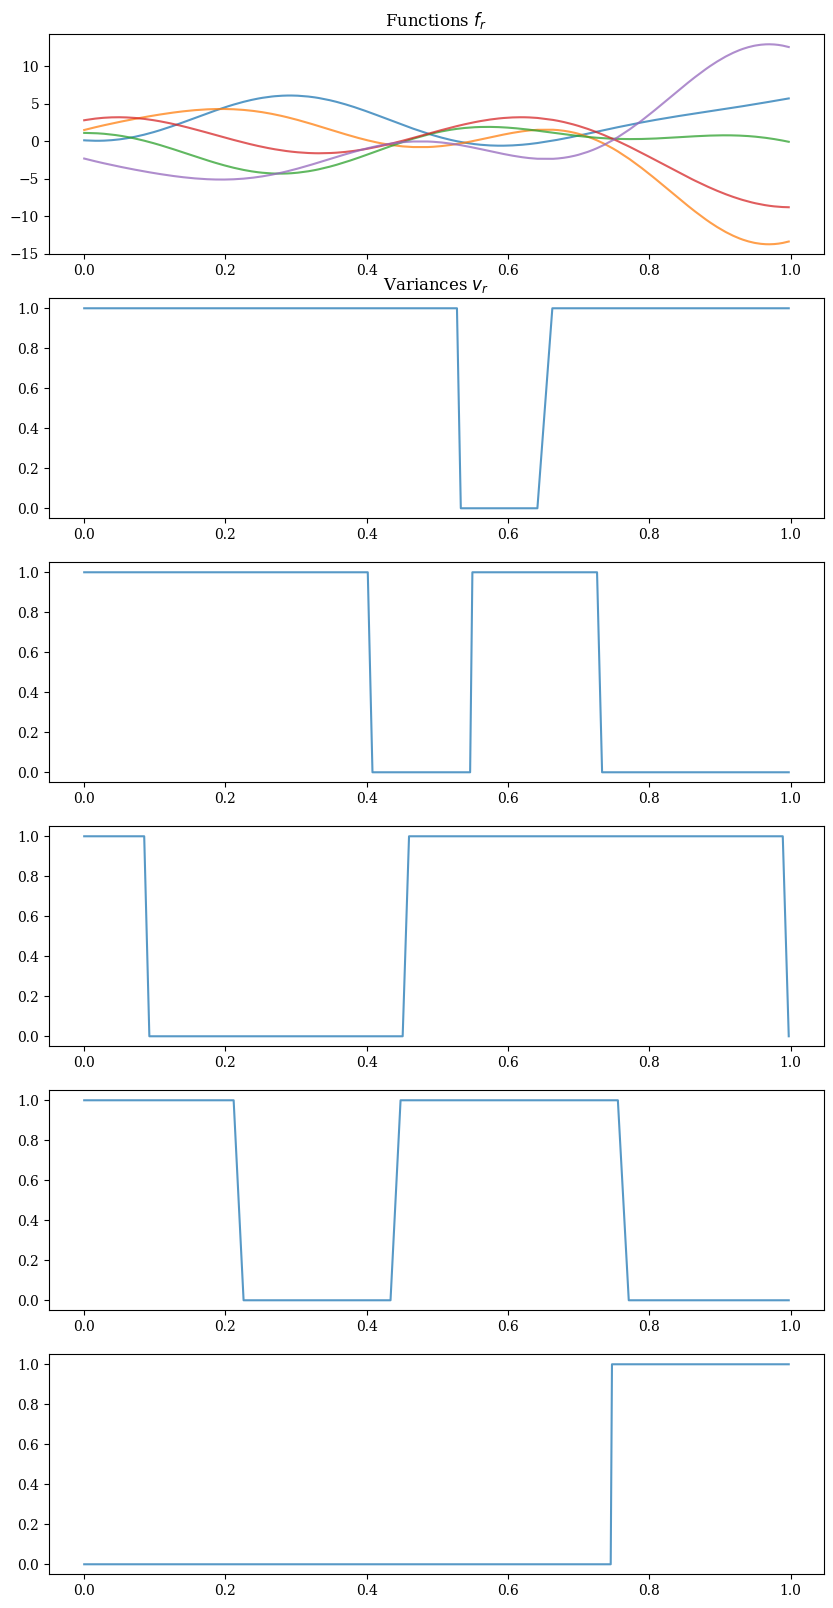

In [ ]:
F_r = []
Lam_r = []
plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.figure(figsize=(10, 20))
for r in range(R):
    f_r = np.zeros((Xtrain.shape[0], 1))
    rho_r = np.zeros((Xtrain.shape[0], 1))
    for q in range(3):
        f_r += W[q][r].T*u_q[:,q,None]
    F_r.append(f_r)
    lam_r = Sigmoid(f_r)
    lam_r[lam_r>0.5] = 1
    lam_r[lam_r<=0.5] = 0
    Lam_r.append(lam_r)

    #Plots
    plt.subplot(6,1,1)
    plt.plot(Xtrain, f_r, alpha=0.75, label='$f_'+str(r+1)+'$')
    plt.subplot(6,1,r+2)
    plt.plot(Xtrain, lam_r, alpha=0.75, label='$v_'+str(r+1)+'$')
plt.subplot(6,1,1)
plt.title(r'Functions $f_r$')
#plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.subplot(6,1,2)
plt.title(r'Variances $v_r$')
#plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Lam_r = [np.ones((100,1))]*5

In [ ]:
Lam_r[0].shape

Fourth, given the labelers' paramters, we simulate the annotations from multiple labelers.

In [ ]:
seed = 100
np.random.seed(seed)
Ytrain = np.ones((N, R))
for r in range(R):
    aux = ytrain.copy()
    for n in range(N):
        if Lam_r[r][n] == 0:
            labels = np.arange(1, K+1)
            a = np.where(labels==ytrain[n])
            labels = np.delete(labels, a)
            idxlabels = np.random.permutation(K-1)
            aux[n] = labels[idxlabels[0]]
    Ytrain[:,r] = aux.flatten()

Finally, it is common to find that the labelers do not have access to the entire dataset. Hence, we simulate such a scenario by introducing a binary variable $ian_{r,n}$, which is one if the annotator $r$ labeled the instance $n$, and zero in otherwise.

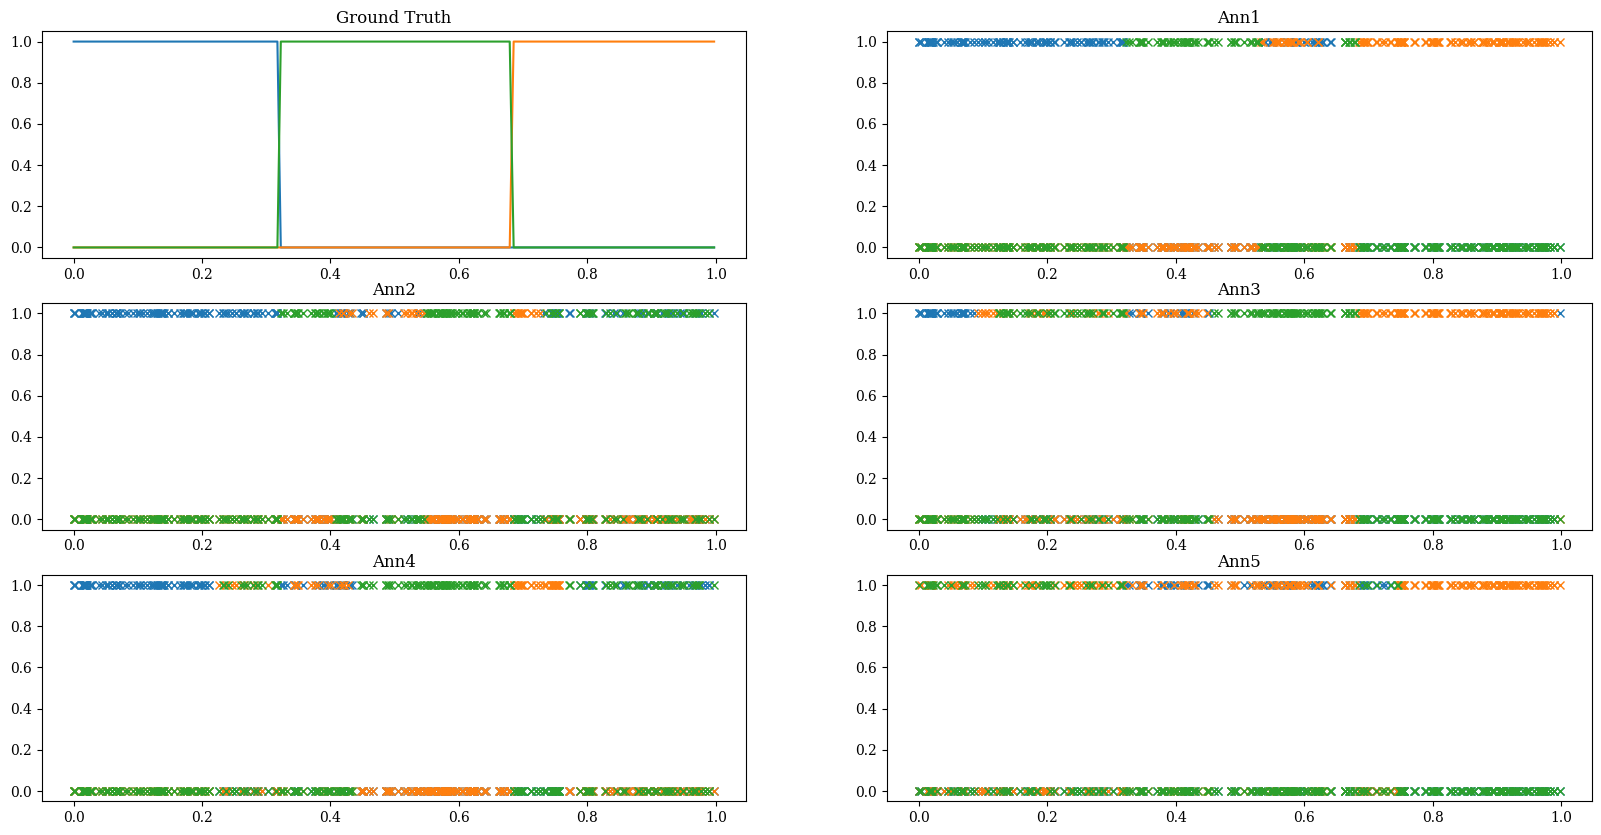

In [ ]:
seed = 100
np.random.seed(seed)
iAnn = np.zeros((N, R), dtype=int) # this indicates if the annotator r labels the nth sample.
Nr = np.ones((R), dtype=int)*int(np.floor(N*NrP))
for r in range(R):
    if r < R-1:
        indexR = np.random.permutation(range(N))[:Nr[r]]
        iAnn[indexR,r] = 1
    else:
        iSimm = np.sum(iAnn, axis=1)
        idxZero = np.asarray([i for (i, val) in enumerate(iSimm) if val == 0])
        Nzeros = idxZero.shape[0]
        idx2Choose = np.arange(N)
        if Nzeros == 0:
            indexR = np.random.permutation(range(N))[:Nr[r]]
            iAnn[indexR,r] = 1
        else:
            idx2Choose = np.delete(idx2Choose, idxZero)
            N2chose = idx2Choose.shape[0]
            idxNoZero = np.random.permutation(N2chose)[:(Nr[r] - Nzeros)]
            idxTot = np.concatenate((idxZero, idx2Choose[idxNoZero]))
            iAnn[idxTot,r] = 1

# Now, we verify that all the samples were labeled at least once
Nr = (np.sum(iAnn,0))
iSimm = np.sum(iAnn, axis=1)
if np.asarray([i for (i, val) in enumerate(iSimm) if val == 0]).sum() == 0:
    ValueError("all the samples must be labeled at least once")

# Finally, if iAnn=0 we assign a reference value to indicate a missing value
Vref = -1e-20
plt.figure(figsize=(20, 10))
plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.subplot(3,2,1)
plt.title('Ground Truth')
plt.plot(X, Yhat, label='Ground Truth')
for r in range(R):
    Ytrain[iAnn[:,r] == 0, r] = Vref
    auxY = one_of_K(Ytrain[:,r:r+1], K)
    plt.subplot(3,2,r+2)
    plt.plot(Xtrain[iAnn[:,r] == 1, :], auxY[iAnn[:,r] == 1, :], 'x', label='Ann'+str(r+1))
    plt.title('Ann'+str(r+1))

Ymax = Ytrain.flatten().max()
plt.show()

In [ ]:
#annotators performance
Acc = np.zeros((R+1,1))
for r in range(R):
    Acc[r,:] = accuracy_score(ytrain, Ytrain[:,r])
Acc[-1,:] = accuracy_score(ytrain, MAjVot(Ytrain, K))
NameCol = ['Accuracy']
NameIdx = ['Annotator_1','Annotator_2','Annotator_3','Annotator_4','Annotator_5','MajorityVoting']
Per = pd.DataFrame(Acc, columns =NameCol, index=NameIdx)
Per

,Accuracy
Annotator_1,0.846667
Annotator_2,0.596667
Annotator_3,0.663333
Annotator_4,0.556667
Annotator_5,0.276667
MajorityVoting,0.833333


In [ ]:
Xtrain = np.asarray(Xtrain).astype(np.float64)
if Xtrain.ndim == 1:
    Xtrain = Xtrain.reshape(-1, 1)

Ytrain = np.asarray(Ytrain).astype(np.float64)

train_dataset = tf.data.Dataset.from_tensor_slices((Xtrain, Ytrain)).repeat()

NameError: name 'tf' is not defined

## 4. Correlated Chained Gaussian processes for multiple annotators (CCGPMA) using a Generalized cross-entropy function as a log P
We use CCGPMA to solve the multi-class classification problem in the context of multiple annotators. For this, we use a generalized cross entropy function to code the log of the likelihood function.


We need to create a new likelihood function. We should define a class with at least three methods:
1. _log_prob
2. _variational_expectations
3. _predict_mean_and_var


### 1. *_log_prob*. For multiclass classification we use a Categorical likelihood.

$$p\left(\mathbf{Y}|\mathbf{f}^{(1)}, \dots , \mathbf{f}^{(K)}, \mathbf{f}^{(K+1)}, \dots , \mathbf{f}^{(K+R)}\right) = \prod_{i=1}^N\prod_{r=1}^R\left(\prod_{k=1}^K (\zeta_{ik})^{\delta(y_i^{(r)}, k)}\right)^{\lambda_{i}^{(r)}}\left(\frac{1}{K}\right)^{1-\lambda_{i}^{(r)}},$$

where $$\zeta_{ik} = \operatorname{softmax}\left(f_i^{(1)}, f_i^{(2)}, \dots ,f_i^{(K)}\right) = \frac{\exp({f_i}^{(k)})}{\sum_{l=1}^K\exp({f_i^{(l)}})},$$ $f_i^{(k)}$ is the output of the $k$-th Gaussian proces for sample $\mathbf{x}_i$. Besides,

$$\delta(y_i^{(r)}, k) = \begin{cases} 1, & y_i^{(r)}=k\\
0, & \mbox{otherwise} \end{cases}.$$

On the other hand,

$$\lambda_{i}^{(r)} = \sigma(f_i^{(K+r)})$$

 Hence,

$$\begin{align} \log p\left(\mathbf{Y}|\mathbf{f}^{(1)}, \dots , \mathbf{f}^{(K)}, \mathbf{f}^{(K+1)}, \dots , \mathbf{f}^{(K+R)}\right) &= \sum_{i=1}^N\sum_{r=1}^R \lambda_{i}^{(r)}\underbrace{\left(\sum_{k=1}^K\delta(y_i^{(r)}, k)\log(\zeta_{ik})\right)}_{\mbox{Cross-entropy}} + \left(1 - \lambda_{i}^{(r)}\right)\log\left(\frac{1}{K}\right).
\end{align}$$

We change the cross entropy function for a generalized cross entropy functions, which is more robust under the presence of noise labels. In that sense,

$$\log p\left(\mathbf{Y}|\mathbf{f}^{(1)}, \dots , \mathbf{f}^{(K)}, \mathbf{f}^{(K+1)}, \dots , \mathbf{f}^{(K+R)}\right) = \frac{1}{q}\sum_{i=1}^N\sum_{r=1}^R \lambda_{i}^{(r)}\left(-\sum_{k=1}^K\delta(y_i^{(r)}, k)\left(1 - \zeta_{ik}^{q}\right)\right) - \left(1 - \lambda_{i}^{(r)}\right)\left(1 - \frac{1}{K^{q}}\right).$$

### 2. *_variational_expectations*. Now we need to compute the expectations of the log likelihood w.r.t. the variational posterior distributions $q(\mathbf{f}^{(1)}), \dots ,q(\mathbf{f}^{(K)}),q(\mathbf{f}^{(K+1)}),\dots , q(\mathbf{f}^{(K+R)})$, where each distribution follows a multivariate Gaussian distribution with mean $F_{mu}$ and a given covariance; however, since we assume independence in the likelihood function, we don't need the covariance but the variance $F_{var}$.

$$\begin{align}\mathbb{E}_{q(\mathbf{f}^{(1)}), \dots ,q(\mathbf{f}^{(K)}),q(\mathbf{f}^{(K+1)}),\dots , q(\mathbf{f}^{(K+R)})}[\log p(\mathbf{Y}|\mathbf{f})] &= \mathbb{E}_{q(\mathbf{f}^{(1)}), \dots ,q(\mathbf{f}^{(K)}),q(\mathbf{f}^{(K+1)}),\dots , q(\mathbf{f}^{(K+R)})}\left[\frac{1}{q}\sum_{i=1}^N\sum_{r=1}^R \lambda_{i}^{(r)}\left(-\sum_{k=1}^K\delta(y_i^{(r)}, k)\left(1 - \zeta_{ik}^{q}\right)\right) - \left(1 - \lambda_{i}^{(r)}\right)\left(1 - \frac{1}{K^{q}}\right)\right]\\
&= \frac{1}{q}\sum_{i=1}^N\sum_{r=1}^R \mathbb{E}_{q(\mathbf{f}^{(K+r)})}\left[\lambda_{i}^{(r)}\right]\left(-\sum_{k=1}^K\delta(y_i^{(r)}, k)\mathbb{E}_{q(\mathbf{f^{(1)}}), \dots ,q(\mathbf{f^{(K)}})}\left[\left(1 - \zeta_{ik}^{q}\right)\right]\right) - \left(1 - \mathbb{E}_{q(\mathbf{f}^{(K+r)})}\left[\lambda_{i}^{(r)}\right]\right)\left(1 - \frac{1}{K^{q}}\right)\end{align},$$

where
$$\mathbb{E}_{q(\mathbf{f^{(1)}}), \dots ,q(\mathbf{f^{(K)}})}\left[\left(1 - \zeta_{ik}^{q}\right)\right] = \int \dots \int
\left(1 - \zeta_{ik}^{q}\right)q(\mathbf{f^{(1)}}), \dots ,q(\mathbf{f^{(K)}}) d\mathbf{f^{(K+r)}}, \dots ,d\mathbf{f^{(K)}}.$$
$$\mathbb{E}_{q(\mathbf{f^{(1)}})}\left[\lambda_{i}^{(r)}\right] = \int
\lambda_{i}^{(r)}q(\mathbf{f^{(K+r)}})d\mathbf{f^{(K+r)}}.$$

The above integral has not anlytical solution; thus, we resort to a numerical approximation, especifically, we use MonteCarlo sampling.

### 3. *_predict_mean_and_var*. Finally, we need to define the mean and variance of prediction distribution for a new sample $\mathbf{x}_{*}$.

- Predictive distributions for the classification function

$$\operatorname{mean} = \mathbb{E}\left[\operatorname{softmax}\left(f_{*}^{(1)}, \dots ,f_{*}^{(K)}\right)\right] = \int\dots\int \operatorname{softmax}\left(f_{*}^{(1)}, \dots ,f_{*}^{(K)}\right)q(f_{*}^{(1)})\dots q(f_{*}^{(K)})df_{*}^{1}\dots df_{*}^{K}.$$

Similarly, $\operatorname{var} = \mathbb{E}\left[\operatorname{softmax}\left(f_{*}^{(1)}, \dots ,f_{*}^{(K)}\right)^2\right] - \mathbb{E}\left[\operatorname{softmax}\left(f_{*}^{(1)}, \dots ,f_{*}^{(K)}\right)\right]^2$, where

$$\mathbb{E}\left[\operatorname{softmax}\left(f_{*}^{(1)}, \dots ,f_{*}^{(K)}\right)^2\right] = \int\dots\int \operatorname{softmax}\left(f_{*}^{(1)}, \dots ,f_{*}^{(K)}\right)^2q(f_{*}^{(1)})\dots q(f_{*}^{(K)})df_{*}^{1}\dots df_{*}^{K}.$$

- Predictive distributions for the annotators performance

$$\operatorname{mean} = \mathbb{E}\left[\sigma\left(f_{*}^{(K+r)}\right)\right] = \int \sigma\left(f_{*}^{(K+r)}\right)q(f_{*}^{(K+r)})df_{*}^{(K+r)}.$$

Similarly, $\operatorname{var} = \mathbb{E}\left[\sigma\left(f_{*}^{(K+r)}\right)^2\right]  - \mathbb{E}\left[\sigma\left(f_{*}^{(K+r)}\right)\right] ^2$, where

$$\mathbb{E}\left[\sigma\left(f_{*}^{(K+r)}\right)^2\right]  = \int \sigma\left(f_{*}^{(K+r)}\right)^2(qf_{*}^{(K+r)})df_{*}^{(K+r)}.$$

In [ ]:
class multiClassMA(gpf.likelihoods.Likelihood):
    def __init__(
        self, num_classes: int, num_ann: int) -> None:
        super().__init__(input_dim=None, latent_dim=num_classes+num_ann, observation_dim=None)
        self.K = num_classes
        self.R = num_ann

    @inherit_check_shapes
    def _log_prob(self, X, F, Y):

        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth= self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)
        zeta = tf.repeat(tf.expand_dims(tf.nn.softmax(F[:,:self.K]), axis = -1), self.R, axis=-1)
        lamb = tf.nn.sigmoid(F[:,self.K:])

        CE = tf.math.reduce_sum(Yh*tf.math.log(zeta), axis=1)

        return -tf.math.reduce_sum((lamb*CE - (1-lamb)*np.log(self.K)), axis=1)

    def _variational_expectations(self, X, Fmu, Fvar, Y):

        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]

        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth= self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)


        # E_{q(f_{1,n})...q(f_{K,n})}[log zeta]
        Elog  = ndiag_mc(self.log_softmax, 800, m_f, v_f, False)# E[log(softmax(F))]
        Elog_ = tf.repeat(tf.expand_dims(Elog, axis = -1), self.R, axis=-1)
        C_E   = tf.math.reduce_sum((Yh*Elog_), axis = 1)


        # E_{q(g_m^m)}[z_n^m]
        Eq_g = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)


        #Variational Expectation ##########################################
        return tf.math.reduce_sum((Eq_g*C_E - (1-Eq_g)*np.log(self.K)), axis=1)

    def _predict_mean_and_var(self, X, Fmu, Fvar):
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]

        Ez = ndiag_mc(tf.nn.softmax, 800, m_f, v_f, False)# E[(softmax(F))]
        El = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)
        # print(Ez)

        Ez_2 = ndiag_mc(self.softmax_2, 800, m_f, v_f, False)# E[(softmax(F))]
        El_2 = ndiagquad(self.sigmoid_2, 20, m_g, v_g, False)

        return tf.concat([Ez, El], axis = 1), tf.concat([Ez_2-Ez**2, El_2-El**2], axis = 1)

    def _predict_log_density(self, F):
        raise NotImplementedError

    def log_softmax(self, F):
        return tf.math.log(tf.nn.softmax(F))

    def softmax_2(self, F):
        return tf.math.square(tf.nn.softmax(F))

    def sigmoid_2(self, F):
        return tf.math.square(tf.nn.sigmoid(F))

In [ ]:
gpflow_script = """
import os
os.environ['MPLBACKEND'] = 'Agg'
import numpy as np
import tensorflow as tf
import gpflow as gpf
import gpflux
from gpflow.quadrature import ndiag_mc, ndiagquad
from check_shapes import inherit_check_shapes
from sklearn.metrics import accuracy_score, roc_auc_score, normalized_mutual_info_score

# ---- Tus parámetros ----
K = 3   # <-- ajusta
R = 2   # <-- ajusta
N = 200 # <-- ajusta
M = 10

# ---- Carga de datos ----
# Reemplaza esto con tu carga real de datos
# Xtrain = np.load("/tmp/Xtrain.npy")
# Ytrain = np.load("/tmp/Ytrain.npy")
# Xtest  = np.load("/tmp/Xtest.npy")
# ytest  = np.load("/tmp/ytest.npy")

# ---- Likelihood personalizada ----
class multiClassMA(gpf.likelihoods.Likelihood):
    def __init__(self, num_classes, num_ann):
        super().__init__(input_dim=None, latent_dim=num_classes+num_ann, observation_dim=None)
        self.K = num_classes
        self.R = num_ann

    @inherit_check_shapes
    def _log_prob(self, X, F, Y):
        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth=self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)
        zeta = tf.repeat(tf.expand_dims(tf.nn.softmax(F[:,:self.K]), axis=-1), self.R, axis=-1)
        lamb = tf.nn.sigmoid(F[:,self.K:])
        CE   = tf.math.reduce_sum(Yh*tf.math.log(zeta), axis=1)
        return -tf.math.reduce_sum((lamb*CE - (1-lamb)*np.log(self.K)), axis=1)

    def _variational_expectations(self, X, Fmu, Fvar, Y):
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]
        iAnn = tf.where(Y == -1e20, tf.zeros_like(Y), tf.ones_like(Y))
        Yh   = tf.one_hot(tf.cast(Y-1, tf.int32), depth=self.K, axis=1)
        Yh   = tf.cast(Yh, tf.float64)
        Elog  = ndiag_mc(self.log_softmax, 800, m_f, v_f, False)
        Elog_ = tf.repeat(tf.expand_dims(Elog, axis=-1), self.R, axis=-1)
        C_E   = tf.math.reduce_sum((Yh*Elog_), axis=1)
        Eq_g  = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)
        return tf.math.reduce_sum((Eq_g*C_E - (1-Eq_g)*np.log(self.K)), axis=1)

    def _predict_mean_and_var(self, X, Fmu, Fvar):
        m_f, m_g = Fmu[:, :self.K], Fmu[:, self.K:]
        v_f, v_g = Fvar[:, :self.K], Fvar[:, self.K:]
        Ez   = ndiag_mc(tf.nn.softmax, 800, m_f, v_f, False)
        El   = ndiagquad(tf.nn.sigmoid, 20, m_g, v_g, False)
        Ez_2 = ndiag_mc(self.softmax_2, 800, m_f, v_f, False)
        El_2 = ndiagquad(self.sigmoid_2, 20, m_g, v_g, False)
        return tf.concat([Ez, El], axis=1), tf.concat([Ez_2-Ez**2, El_2-El**2], axis=1)

    def _predict_log_density(self, F):
        raise NotImplementedError

    def log_softmax(self, F):
        return tf.math.log(tf.nn.softmax(F))

    def softmax_2(self, F):
        return tf.math.square(tf.nn.softmax(F))

    def sigmoid_2(self, F):
        return tf.math.square(tf.nn.sigmoid(F))

# ---- Modelo ----
L = R + K
Z = np.linspace(Xtrain.min(), Xtrain.max(), M).reshape(-1, 1)

kernel1 = gpf.kernels.SquaredExponential(variance=0.5, lengthscales=1)
inducing_variable1 = gpf.inducing_variables.InducingPoints(Z.copy())
gp_layer1 = gpflux.layers.GPLayer(
    kernel1, inducing_variable1, num_data=N, num_latent_gps=3,
    mean_function=gpf.mean_functions.Zero()
)

Z2 = np.linspace(Xtrain.min(), Xtrain.max(), M).reshape(-1, 1).repeat(3, axis=1)
kernel2 = gpf.kernels.SquaredExponential(variance=0.5, lengthscales=1)
inducing_variable2 = gpf.inducing_variables.InducingPoints(Z2.copy())
gp_layer2 = gpflux.layers.GPLayer(
    kernel2, inducing_variable2, num_data=N, num_latent_gps=L,
    mean_function=gpf.mean_functions.Zero()
)

likelihood_layer = gpflux.layers.LikelihoodLayer(multiClassMA(K, R))
two_layer_dgp = gpflux.models.DeepGP(
    f_layers=[gp_layer1, gp_layer2],
    likelihood=likelihood_layer,
    input_dim=1
)
model = two_layer_dgp.as_training_model()
model.compile(gpf.keras.tf_keras.optimizers.Adam(0.01))

# ---- Entrenamiento ----
history = model.fit(
    {"inputs": Xtrain, "targets": Ytrain},
    batch_size=100,
    epochs=1000,
    verbose=1
)

# ---- Predicciones ----
f_distribution = model({"inputs": Xtest, "targets": ytest})
pY  = f_distribution.y_mean
pYv = f_distribution.y_var

# ---- Guardar resultados ----
np.save("/tmp/pY.npy",    pY.numpy())
np.save("/tmp/pYv.npy",   pYv.numpy())
np.save("/tmp/Xtest.npy", Xtest)
np.save("/tmp/ytest.npy", ytest)
np.save("/tmp/history_loss.npy", np.array(history.history["loss"]))
print("gpflow DONE")
"""

with open("/tmp/run_gpflow.py", "w") as f:
    f.write(gpflow_script)
print("Script escrito OK")

Script escrito OK


In [ ]:
# Ejecutar en el venv
import subprocess
result = subprocess.run(
    ["/opt/gpflow_env/bin/python", "/tmp/run_gpflow.py"],
    capture_output=True, text=True
)
print(result.stdout[-3000:])  # últimas líneas del log
if result.returncode != 0:
    print("STDERR:", result.stderr[-3000:])


STDERR: 2026-05-20 15:26:08.754722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-20 15:26:08.781815: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-20 15:26:08.781879: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-20 15:26:08.798583: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-20 15:26:09.777770: W tenso

In [ ]:
# Defining the Deep GP.
M = 10
L = R+K
# # INDUCING POINTS
Z = np.linspace(X.min(), X.max(), M).reshape(-1, 1)

kernel1 = gpf.kernels.SquaredExponential(variance=0.5, lengthscales=1)
inducing_variable1 = gpf.inducing_variables.InducingPoints(Z.copy())


gp_layer1 = gpflux.layers.GPLayer(
    kernel1, inducing_variable1, num_data=N, num_latent_gps=3,mean_function=gpf.mean_functions.Zero(),
)

Z = np.linspace(X.min(), X.max(), M).reshape(-1, 1).repeat(3, axis=1)
kernel2 = gpf.kernels.SquaredExponential(variance=0.5, lengthscales=1)
inducing_variable2 = gpf.inducing_variables.InducingPoints(Z.copy())
gp_layer2 = gpflux.layers.GPLayer(
    kernel2,
    inducing_variable2,
    num_data=N,
    num_latent_gps=L,
    mean_function=gpf.mean_functions.Zero(),
)

likelihood_layer = gpflux.layers.LikelihoodLayer(multiClassMA(K, R))
two_layer_dgp = gpflux.models.DeepGP(f_layers = [gp_layer1, gp_layer2], likelihood = likelihood_layer, input_dim=1)
model = two_layer_dgp.as_training_model()
model.compile(gpf.keras.tf_keras.optimizers.Adam(0.01))

In [ ]:
history = model.fit(
    {"inputs": Xtrain, "targets": Ytrain},
    batch_size=100,
    epochs=1000,
    verbose=1)

In [ ]:
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [ ]:
f_distribution = model({"inputs": Xtest, "targets": ytest})

In [ ]:
pY, pYv = f_distribution.y_mean, f_distribution.y_var

## 5. Figures  and Perfomance assessment

In [ ]:
plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.figure(figsize=(15, 20))

Mc, Vc = pY.numpy(), abs(pYv.numpy())
M, V = pY.numpy(), abs(pYv.numpy())
Yhat_test = one_of_K(ytest, K)

for r in range(R+1):
    # Original Values
    miny = 0
    maxy = 1
    if r ==0:
        plt.subplot(R+1,3, 3*r+1)
        plt.plot(Xtest, Yhat_test, linewidth=2, alpha=1)
        plt.ylabel("Classification",fontsize=14)
        plt.ylim(miny-0.1, maxy+0.1)
    else:
        plt.subplot(R+1,3, 3*r+1)
        plt.plot(Xtrain, Lam_r[r-1], 'b-', linewidth=2, alpha=1)
        plt.ylabel(r"$"+r"\lambda_"+str(r)+'$', fontsize=18)
        plt.ylim(-0.1, 1.1)

    # CGP
    if r > 0:
        mfc, vfc = Mc[:, K+r-1], Vc[:, K+r-1]
        mf_upperc = mfc + 2*np.sqrt(vfc)
        mf_lowerc = mfc - 2*np.sqrt(vfc)

        plt.subplot(R+1,3, 3*r+2)
        plt.plot(Xtest, (mfc), 'b-', linewidth=2, alpha=1)
        plt.plot(Xtest, (mf_upperc), 'b-', linewidth=4, alpha=0.25)
        plt.plot(Xtest, (mf_lowerc), 'b-', linewidth=4, alpha=0.25)
        plt.ylim(-0.1, 1.1)
    else:
        mfc, vfc = Mc[:, :K], Vc[:, :K]
        mf_upperc = mfc + 2*np.sqrt(vfc)
        mf_lowerc = mfc - 2*np.sqrt(vfc)

        plt.subplot(R+1,3, 3*r+2)
        plt.plot(Xtest, (mfc), linewidth=2, alpha=1)
        plt.gca().set_prop_cycle(None)
        plt.plot(Xtest, (mf_upperc), linewidth=4, alpha=0.25)
        plt.gca().set_prop_cycle(None)
        plt.plot(Xtest, (mf_lowerc), linewidth=4, alpha=0.25)
        plt.ylim(miny-0.1, maxy+0.1)




# Regression performance
auxMc = np.array(np.argmax(Mc[:,:K], 1).reshape(-1,1), dtype=float)+1
auxM = np.array(np.argmax(M[:,:K], 1).reshape(-1,1), dtype=float)+1


AccCCGP  = accuracy_score(ytest, auxM)
AUC_CCGP = roc_auc_score(Yhat_test, M[:,:K])
NMI_CCGP = normalized_mutual_info_score(ytest.flatten(), auxM.flatten())

plt.subplot(R+1,3,1)
plt.title('Ground truth and real reliabilities')
plt.subplot(R+1,3,2)
plt.title('NMI='+"{:.2f}".format(NMI_CCGP*100)+', AUC='+"{:.2f}".format(AUC_CCGP*100)+', Acc='"{:.2f}".format(AccCCGP*100))
plt.show()
plt.savefig('mi_grafico.png', dpi=300, bbox_inches='tight')

In [ ]:
# Save data Mean
for i in range(3):
  A = np.concatenate((Xtest, Mc[:,i:i+1]), axis=1)
  np.savetxt('MA_CCE_Mean' + str(i+1) + '.dat', A)

In [ ]:
# Save data Upper
for i in range(3):
  V = Mc[:,i:i+1]+ 2*np.sqrt(Vc[:,i:i+1])
  V[V>1] = 1
  A = np.concatenate((Xtest, V), axis=1)
  np.savetxt('MA_CCE_Sup' + str(i+1) + '.dat', A)

In [ ]:
# Save data Lower
for i in range(3):
  V = Mc[:,i:i+1]- 2*np.sqrt(Vc[:,i:i+1])
  V[V<0] = 0
  A = np.concatenate((Xtest, V), axis=1)
  np.savetxt('MA_CCE_Low' + str(i+1) + '.dat', A)

In [ ]:
# Save The mean reliabilities
for i in range(3,8):
  A = np.concatenate((Xtest, Mc[:,i:i+1]), axis=1)
  np.savetxt('Reli_Mean_CCE' + str(i-3) + '.dat', A)

In [ ]:
# Save reliabilities Upper
for i in range(3,8):
  V = Mc[:,i:i+1]+ 2*np.sqrt(Vc[:,i:i+1])
  V[V>1] = 1
  A = np.concatenate((Xtest, V), axis=1)
  np.savetxt('Reli_Sup_CCE' + str(i-3) + '.dat', A)

In [ ]:
# Save reliabilities Lower
for i in range(3,8):
  V = Mc[:,i:i+1]- 2*np.sqrt(Vc[:,i:i+1])
  V[V<0] = 0
  A = np.concatenate((Xtest, V), axis=1)
  np.savetxt('Reli_Low_CCE' + str(i-3) + '.dat', A)

# Performance Assessment for the reliabilities

In [ ]:
pY, pYv = m.predict_y(Xtrain)
Mc, Vc = pY.numpy(), abs(pYv.numpy())

In [ ]:
for i in range(5):
  AccCCGP  = accuracy_score(Lam_r[i], np.round(Mc[:,i+3]))
  AUC_CCGP = roc_auc_score(Lam_r[i], Mc[:,i+3])
  NMI_CCGP = normalized_mutual_info_score(Lam_r[i].flatten(), np.round(Mc[:,i+3].flatten()))
  print(AccCCGP,AUC_CCGP,NMI_CCGP)